In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet("../processed/final_master_dataset.parquet")

In [3]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns}")
print(df.dtypes)

Shape: (5598786, 59)
Columns: Index(['mbid', 'bpm', 'bpm_histogram_first_peak_bpm_mean',
       'bpm_histogram_first_peak_bpm_median',
       'bpm_histogram_second_peak_bpm_mean',
       'bpm_histogram_second_peak_bpm_median', 'danceability', 'onset_rate',
       'average_loudness', 'dynamic_complexity', 'mfcc_zero_mean',
       'tuning_frequency', 'tuning_equal_tempered_deviation', 'key_key',
       'key_scale', 'mood_happy_prob', 'mood_aggressive_prob', 'mood_happy',
       'mood_sad', 'mood_relaxed', 'mood_aggressive', 'mood_acoustic',
       'mood_electronic', 'mood_party', 'voice_gender', 'timbre',
       'tonal_atonal', 'voice_instrumental', 'artist_mbid',
       'artist_credit_name', 'release_mbid', 'release_name', 'recording_name',
       'combined_lookup', 'status', 'language', 'script', 'quality',
       'release_year', 'release_month', 'release_day', 'artist_name',
       'artist_type', 'artist_country', 'gender', 'artist_geo_entity',
       'artist_begin_year', 'artist_end_

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5598786 entries, 0 to 5598785
Data columns (total 59 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_key                               str    
 14  key_scale                             str    
 15  mood_happy_prob           

Understanding the features

* mbid: musicbrainz id
* bpm: beats per minute
* bpm_histogram_first_peak_bpm_mean  : (for rhythm) average tempo (beats per minute) of the most prominent, dominant rhythm found in a song    
* bpm_histogram_first_peak_bpm_median  : median tempo of the most dominant rhythmic pulse in the song
* bpm_histogram_second_peak_bpm_mean  : average tempo of second most dominate rhythm in song. 
* bpm_histogram_second_peak_bpm_median  median tempo of the second most dominnat rhythmic pulse
* dancebility: the danceability value. Normal values range from 0 to ~3. The higher, the more danceable.
* onset_rate: average number of note attacks or sonic events detected per second in a track (onset is beginning of a sound or note where volumne sharply spikes) - measures rhythmic density or busyness of music
* average loudness: dynamic range descriptor. It rescales average loudness, computed on 2sec windows with 1 sec overlap, into the [0,1] interval. The value of 0 corresponds to signals with large dynamic range, 1 corresponds to signal with little dynamic range.
* dynamic_complexity: dynamic complexity computed on 2sec windows with 1sec overlap.
* mfcc_zero_mean - average valeu of hte very first mel frequency cepstral coeffciinet across the track - overall loudness footprint and basic timbral texture
* tuning_frequency: estimated tuning frequency [Hz]. 
* tuning_equal_tempered_deviation: measure of the deviation of HPCP local maxima with respect to equal-tempered bins
* key: key
* key_scale: major minor, etc
* mood_ features: the probability or binary of mood of song
* voice_gender
* timbre:
* tonal_atonal                          str    
* voice_instrumental                    str    
* artist_mbid                           str    
* artist_credit_name                    str    
* release_mbid                          str    
* release_name                          str    
* recording_name                        str    
* combined_lookup                       str    
* status                                str    
* language                              float64
* script                                float64
* quality                               float64
* release_year                          float64
* release_month                         float64
* release_day                           float64
* artist_name                           str    
* artist_type                           float64
* artist_country                        str    
* gender                                str    
* artist_geo_entity                     float64
* artist_begin_year                     str    
* artist_end_year                       float64
* ended                                 str    
* release_group_top_genre               str    
* release_group_top_genre_votes         float64
* release_group_all_genres              str    
* artist_top_genre                      str    
* artist_top_genre_votes                float64
* artist_all_genres                     str    
* recording_top_genre                   str    
* recording_top_genre_votes             float64
* recording_all_genres                  str    
* genre                                 str 

 gender: 1 → Male
2 → Female
3 → Other
4 → Not applicable
5 → Non-binary



In [5]:
df.isnull().sum()

mbid                                          0
bpm                                           0
bpm_histogram_first_peak_bpm_mean             0
bpm_histogram_first_peak_bpm_median           0
bpm_histogram_second_peak_bpm_mean            0
bpm_histogram_second_peak_bpm_median          0
danceability                                  0
onset_rate                                    0
average_loudness                              0
dynamic_complexity                            0
mfcc_zero_mean                                0
tuning_frequency                              0
tuning_equal_tempered_deviation               0
key_key                                       0
key_scale                                     0
mood_happy_prob                               0
mood_aggressive_prob                          0
mood_happy                                    0
mood_sad                                      0
mood_relaxed                                  0
mood_aggressive                         

In [6]:
df['quality'].value_counts()

quality
-1.0    5569027
 2.0      12990
 1.0       6383
 0.0       4951
Name: count, dtype: int64

In [7]:
df['status'].value_counts()

status
1     5380246
3       61967
2       49676
4        8374
5        5246
38        152
6         110
Name: count, dtype: int64

In [8]:
df['script'].value_counts()

script
28.0     5079133
85.0      149229
160.0      32888
31.0       30171
94.0        6568
93.0        3311
43.0        3053
22.0        2511
101.0       1250
11.0        1184
111.0        960
92.0         521
18.0         510
84.0         412
65.0         325
112.0        239
36.0          54
50.0          49
83.0          33
87.0          28
26.0          21
53.0          20
100.0         15
64.0          15
35.0           9
63.0           6
59.0           6
86.0           6
62.0           6
23.0           2
4.0            1
Name: count, dtype: int64

I want to predict decade (what era does this song sound like) based off audio features alone (without including bias such as artist_country, artist_name, release_year, etc) So I will drop the following columns

In [3]:
cols_to_drop = [
    "artist_mbid",
    "artist_credit_name",
    "release_mbid",
    "release_name",
    "recording_name",
    "combined_lookup",
    "status",
    "language",
    "script",
    "quality",
    "release_month",
    "release_day",
    "artist_name",
    "artist_type",
    "artist_country",
    "gender",
    "artist_geo_entity",
    "artist_begin_year",
    "artist_end_year",
    "ended",
    "release_group_top_genre",
    "release_group_top_genre_votes",
    "release_group_all_genres",
    "artist_top_genre",
    "artist_top_genre_votes",
    "artist_all_genres",
    "recording_top_genre",
    "recording_top_genre_votes",
    "recording_all_genres",
    "genre"
]

In [4]:
df.drop(columns = cols_to_drop, inplace = True)

In [15]:
df.isna().sum()

mbid                                         0
bpm                                          0
bpm_histogram_first_peak_bpm_mean            0
bpm_histogram_first_peak_bpm_median          0
bpm_histogram_second_peak_bpm_mean           0
bpm_histogram_second_peak_bpm_median         0
danceability                                 0
onset_rate                                   0
average_loudness                             0
dynamic_complexity                           0
mfcc_zero_mean                               0
tuning_frequency                             0
tuning_equal_tempered_deviation              0
key_key                                      0
key_scale                                    0
mood_happy_prob                              0
mood_aggressive_prob                         0
mood_happy                                   0
mood_sad                                     0
mood_relaxed                                 0
mood_aggressive                              0
mood_acoustic

Since ~5M rows total, decide to just drop the NAs from release_year

In [5]:
df.dropna(subset = ['release_year'], inplace = True)

In [6]:
df.isna().sum()

mbid                                    0
bpm                                     0
bpm_histogram_first_peak_bpm_mean       0
bpm_histogram_first_peak_bpm_median     0
bpm_histogram_second_peak_bpm_mean      0
bpm_histogram_second_peak_bpm_median    0
danceability                            0
onset_rate                              0
average_loudness                        0
dynamic_complexity                      0
mfcc_zero_mean                          0
tuning_frequency                        0
tuning_equal_tempered_deviation         0
key_key                                 0
key_scale                               0
mood_happy_prob                         0
mood_aggressive_prob                    0
mood_happy                              0
mood_sad                                0
mood_relaxed                            0
mood_aggressive                         0
mood_acoustic                           0
mood_electronic                         0
mood_party                        

Now, need to create decades target by binning release_year

Code to view the counts of each release_year

In [ ]:
from itables import show
from IPython.display import display, HTML

# 1. Temporarily allow pandas to output all rows without cutting them off
with pd.option_context('display.max_rows', None):
    # 2. Convert value counts to an HTML table string
    html_table = df['release_year'].value_counts().to_frame().to_html()

# 3. Put that table inside a scrollable box (400 pixels high)
scroll_box = f"""
<div style="max-height: 400px; overflow-y: scroll; border: 1px solid #ccc; padding: 10px;">
    {html_table}
</div>
"""

display(HTML(scroll_box))

,count
release_year,
2018.0,250617
2016.0,250169
2017.0,249206
2020.0,248973
2019.0,244947
2015.0,239291
2014.0,235822
2013.0,223926
2012.0,205638


Decide to keep all years after 1930

In [ ]:
df = df[df['release_year'] >= 1930]

Create decade column by binning release_year by decade

In [10]:
df['decade'] = (df['release_year'] // 10 * 10).astype(int)


In [11]:
df['decade'].value_counts()

decade
2010    2272728
2000    1383814
1990     793412
2020     452101
1980     255992
1970     143567
1960      79474
1950      22312
1930       1410
1940       1237
Name: count, dtype: int64

Encode pre-1960s as just 1950

In [ ]:
genre_mapping = {
    1930 : 1950,
    1940 : 1950,
    1950 : 1950,
}

df['decade'] = df['decade'].replace(genre_mapping)

In [13]:
df['decade'].value_counts()

decade
2010    2272728
2000    1383814
1990     793412
2020     452101
1980     255992
1970     143567
1960      79474
1950      24959
Name: count, dtype: int64

Undersample majority classes

In [14]:
from sklearn.utils import resample
import pandas as pd

CAP = 250000

balanced_dfs = []

for decade in df['decade'].unique():
    decade_df = df[df['decade'] == decade]

    if len(decade_df) > CAP:

        decade_df = resample(decade_df, replace = False, n_samples = CAP, random_state = 42)

    balanced_dfs.append(decade_df)

df_balanced = pd.concat(balanced_dfs)

In [15]:
df_balanced['decade'].value_counts()

decade
2000    250000
1990    250000
2010    250000
2020    250000
1980    250000
1970    143567
1960     79474
1950     24959
Name: count, dtype: int64

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 5406047 entries, 0 to 5598785
Data columns (total 30 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_key                               str    
 14  key_scale                             str    
 15  mood_happy_prob                

Get the numeric columns to plot and examine distribution

In [19]:
numeric_cols = [col for col in df.columns if df[col].dtype != 'str']

In [20]:
numeric_cols

['bpm',
 'bpm_histogram_first_peak_bpm_mean',
 'bpm_histogram_first_peak_bpm_median',
 'bpm_histogram_second_peak_bpm_mean',
 'bpm_histogram_second_peak_bpm_median',
 'danceability',
 'onset_rate',
 'average_loudness',
 'dynamic_complexity',
 'mfcc_zero_mean',
 'tuning_frequency',
 'tuning_equal_tempered_deviation',
 'mood_happy_prob',
 'mood_aggressive_prob',
 'release_year',
 'decade']

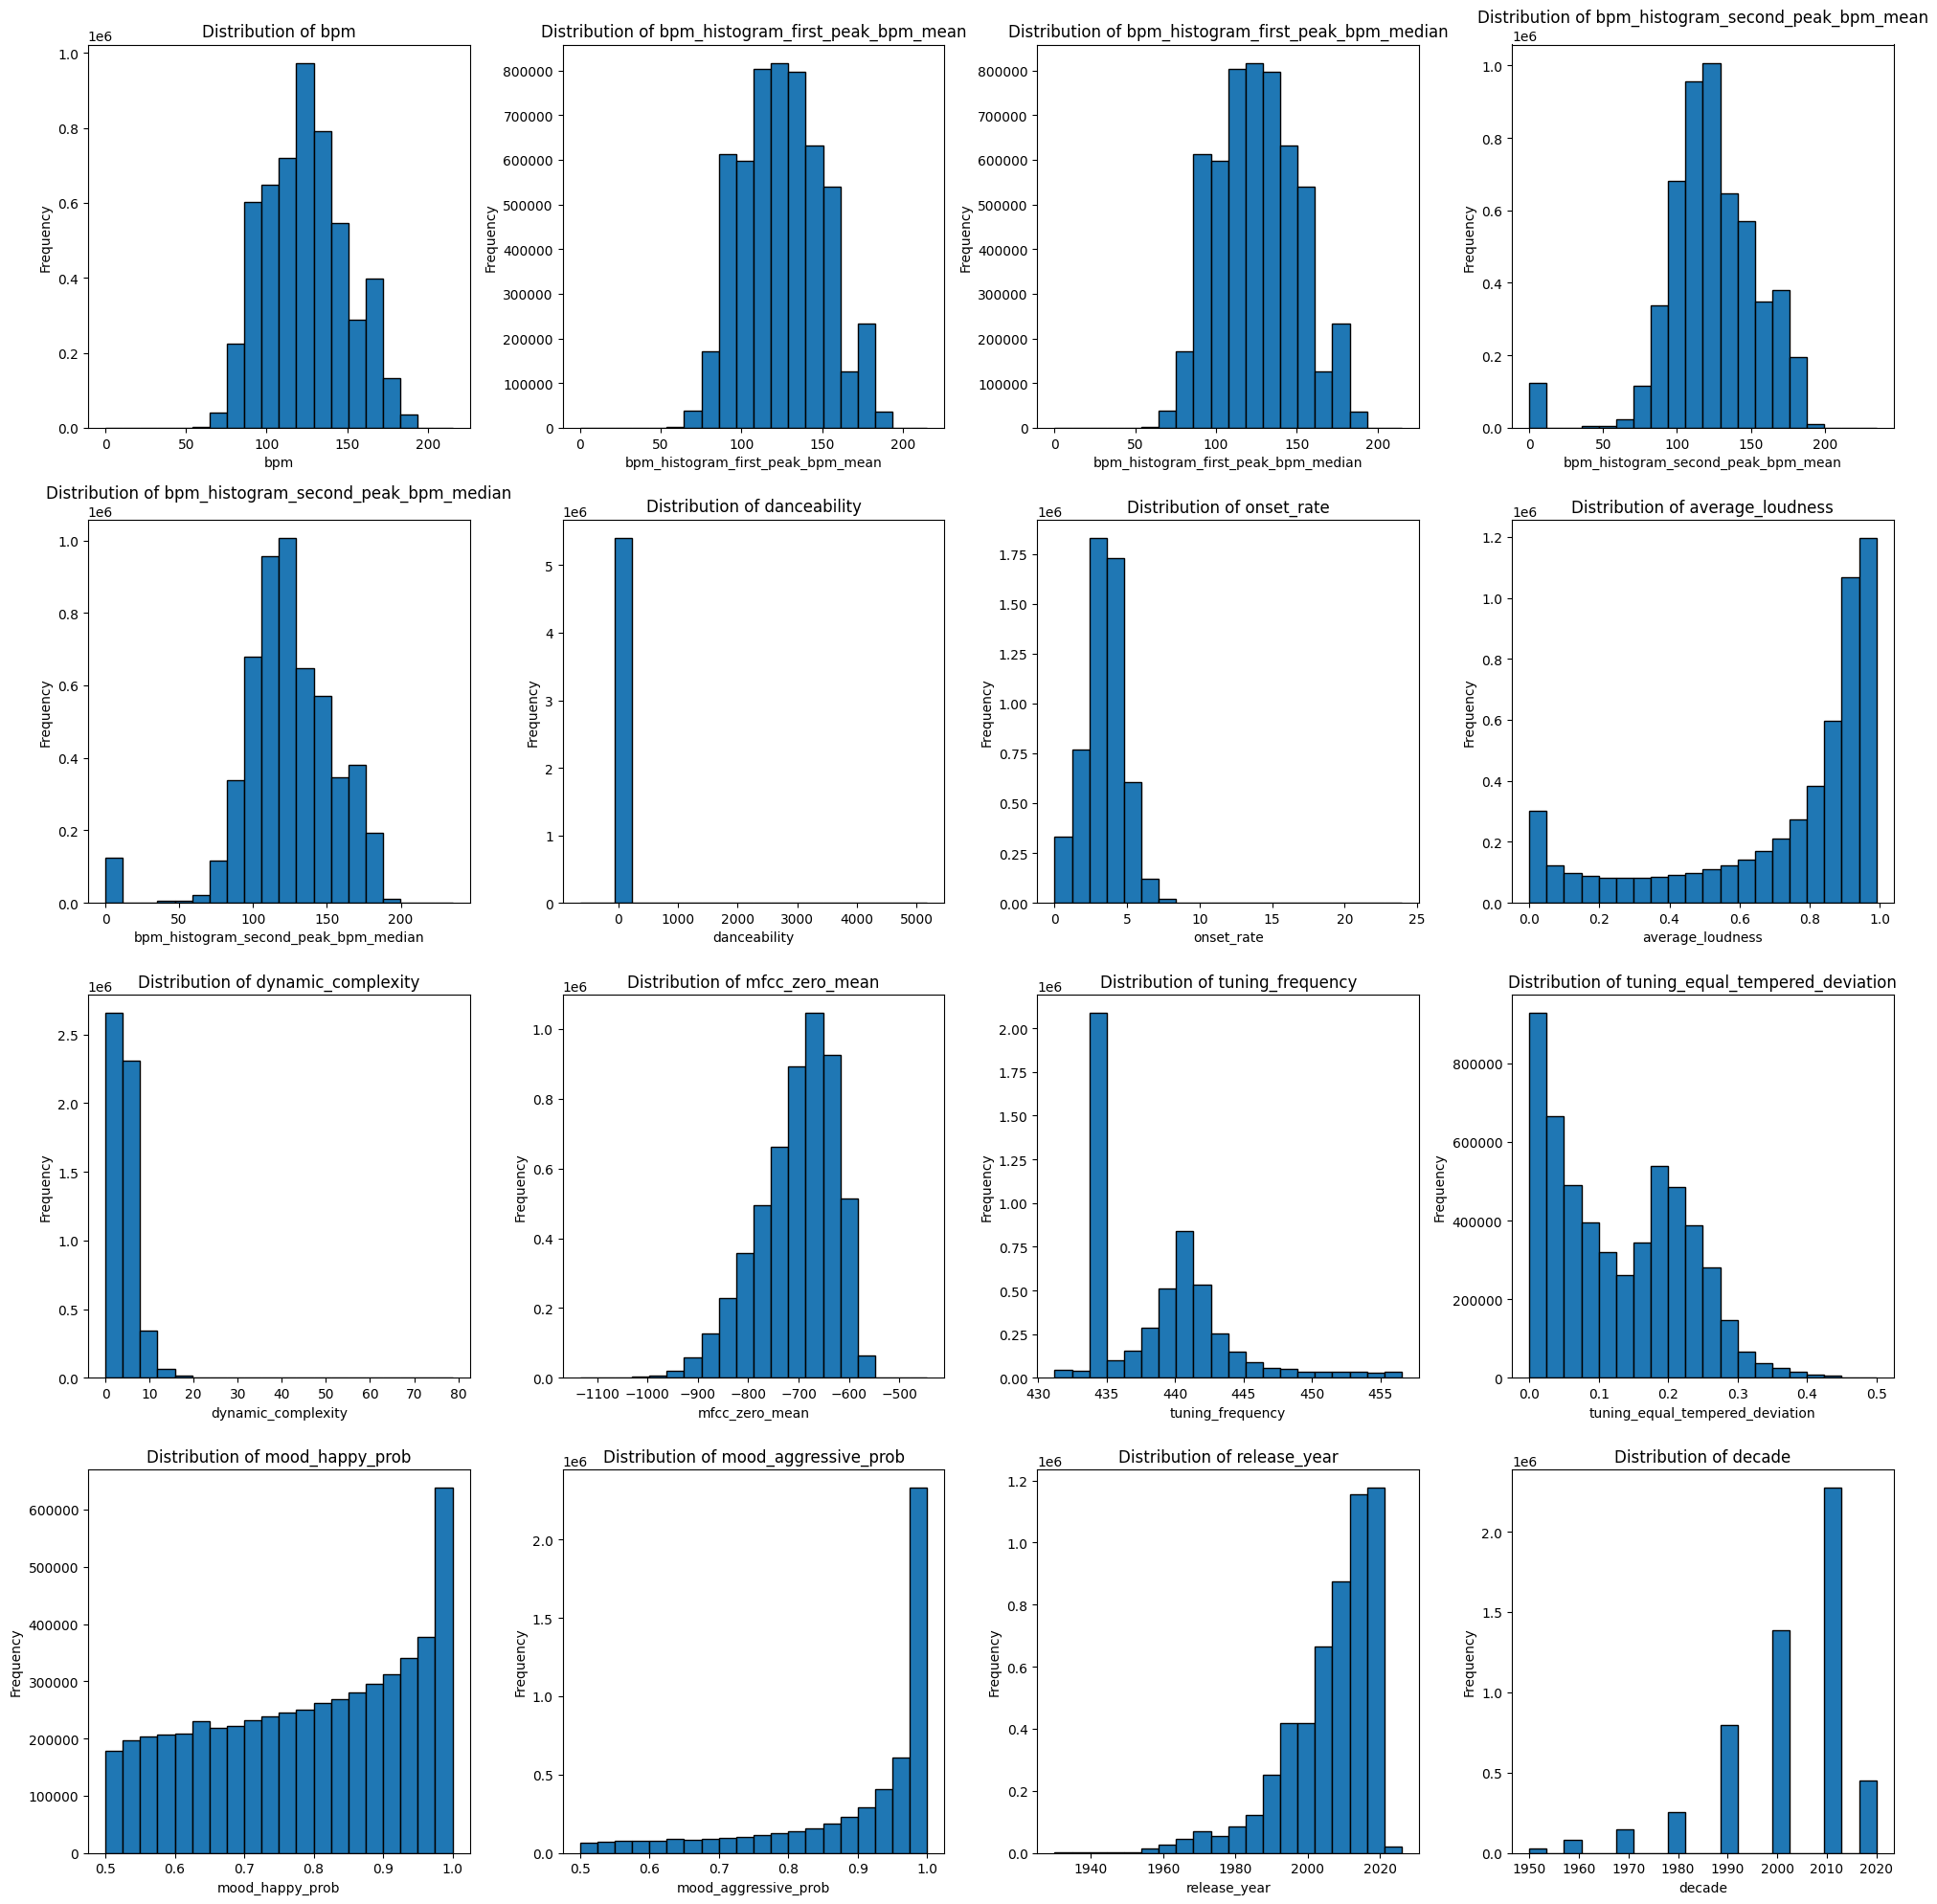

In [21]:
num_cols = len(numeric_cols)
n_cols = 4
n_rows = 4

fig, axes = plt.subplots(nrows=n_rows, ncols = n_cols, figsize=( 20,20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins = 20, edgecolor = 'black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


View statistics of numeric columns

In [22]:
df.describe()

,bpm,bpm_histogram_first_peak_bpm_mean,bpm_histogram_first_peak_bpm_median,bpm_histogram_second_peak_bpm_mean,bpm_histogram_second_peak_bpm_median,danceability,onset_rate,average_loudness,dynamic_complexity,mfcc_zero_mean,tuning_frequency,tuning_equal_tempered_deviation,mood_happy_prob,mood_aggressive_prob,release_year,decade
count,5.406047e+06,5.406047e+06,5.406047e+06,5.406047e+06,5.406047e+06,5.406047e+06,5.406047e+06,5.406047e+06,5.406047e+06,5.406047e+06,5.406047e+06,5.406047e+06,5.406047e+06,5.406047e+06,5.406047e+06,5.406047e+06
mean,1.240529e+02,1.244602e+02,1.244602e+02,1.243088e+02,1.243088e+02,1.147936e+00,3.422508e+00,7.173942e-01,4.523035e+00,-7.043093e+02,4.386524e+02,1.285609e-01,7.903501e-01,8.996633e-01,2.006402e+03,2.001846e+03
std,2.491428e+01,2.483183e+01,2.483183e+01,3.207464e+01,3.207464e+01,2.386333e+00,1.323252e+00,2.966740e-01,2.588939e+00,7.687401e+01,4.733463e+00,9.435546e-02,1.487778e-01,1.301970e-01,1.254899e+01,1.283220e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.389771e+02,0.000000e+00,2.084907e-08,0.000000e+00,-1.134098e+03,4.311939e+02,0.000000e+00,5.000000e-01,5.000000e-01,1.930000e+03,1.950000e+03
25%,1.047880e+02,1.050000e+02,1.050000e+02,1.080000e+02,1.080000e+02,9.935932e-01,2.616428e+00,5.888858e-01,2.947215e+00,-7.517441e+02,4.341931e+02,3.984134e-02,6.641343e-01,8.495228e-01,2.000000e+03,2.000000e+03
50%,1.232026e+02,1.230000e+02,1.230000e+02,1.230000e+02,1.230000e+02,1.111795e+00,3.462116e+00,8.576918e-01,3.971468e+00,-6.911597e+02,4.387310e+02,1.162721e-01,8.069189e-01,9.611914e-01,2.010000e+03,2.010000e+03
75%,1.400457e+02,1.400000e+02,1.400000e+02,1.440000e+02,1.440000e+02,1.251448e+00,4.286072e+00,9.356986e-01,5.384655e+00,-6.461839e+02,4.412726e+02,2.052194e-01,9.252791e-01,9.949974e-01,2.016000e+03,2.010000e+03
max,2.153320e+02,2.150000e+02,2.150000e+02,2.350000e+02,2.350000e+02,5.173636e+03,2.393871e+01,9.906840e-01,7.868979e+01,-4.445597e+02,4.565703e+02,5.000000e-01,1.000000e+00,1.000000e+00,2.026000e+03,2.020000e+03


Having 0 for bpm related features seems incorrect so will drop those

In [23]:
len(df[df['bpm_histogram_second_peak_bpm_mean'] < 20])

125027

In [24]:
df = df[df['bpm'] >= 20]
df = df[df['bpm_histogram_first_peak_bpm_mean'] >= 20]
df = df[df['bpm_histogram_first_peak_bpm_median'] >= 20]
df = df[df['bpm_histogram_second_peak_bpm_mean'] >= 20]
df = df[df['bpm_histogram_second_peak_bpm_median'] >= 20]

Based on the description, danceability should be between 0 and around 3: "danceability (real) - the danceability value. Normal values range from 0 to ~3. The higher, the more danceable."

In [25]:
df['danceability'].describe()

count    5.281020e+06
mean     1.143138e+00
std      2.280760e+00
min     -3.040482e+01
25%      9.914816e-01
50%      1.108786e+00
75%      1.246332e+00
max      5.173636e+03
Name: danceability, dtype: float64

In [26]:
len(df[df['danceability'] < 0])

12

In [27]:
len(df[df['danceability'] > 3])

1752

Set danceability as between 0 and 3

In [28]:
df = df[df['danceability'].between(0, 3)]

MFCCs are:

"log-scaled spectral features often centered around negative values after processing.
Frequently mean-normalized (“zero_mean”) - shifts distribution below 0.
Not bounded to any fixed range"

In [29]:
df['mfcc_zero_mean'].describe()

count    5.279256e+06
mean    -7.045790e+02
std      7.701308e+01
min     -1.134098e+03
25%     -7.524496e+02
50%     -6.914681e+02
75%     -6.461630e+02
max     -4.445597e+02
Name: mfcc_zero_mean, dtype: float64

In [30]:
df['tuning_equal_tempered_deviation'].describe()

count    5.279256e+06
mean     1.278520e-01
std      9.429978e-02
min      0.000000e+00
25%      3.930080e-02
50%      1.145806e-01
75%      2.047688e-01
max      5.000000e-01
Name: tuning_equal_tempered_deviation, dtype: float64

Check the distributions again

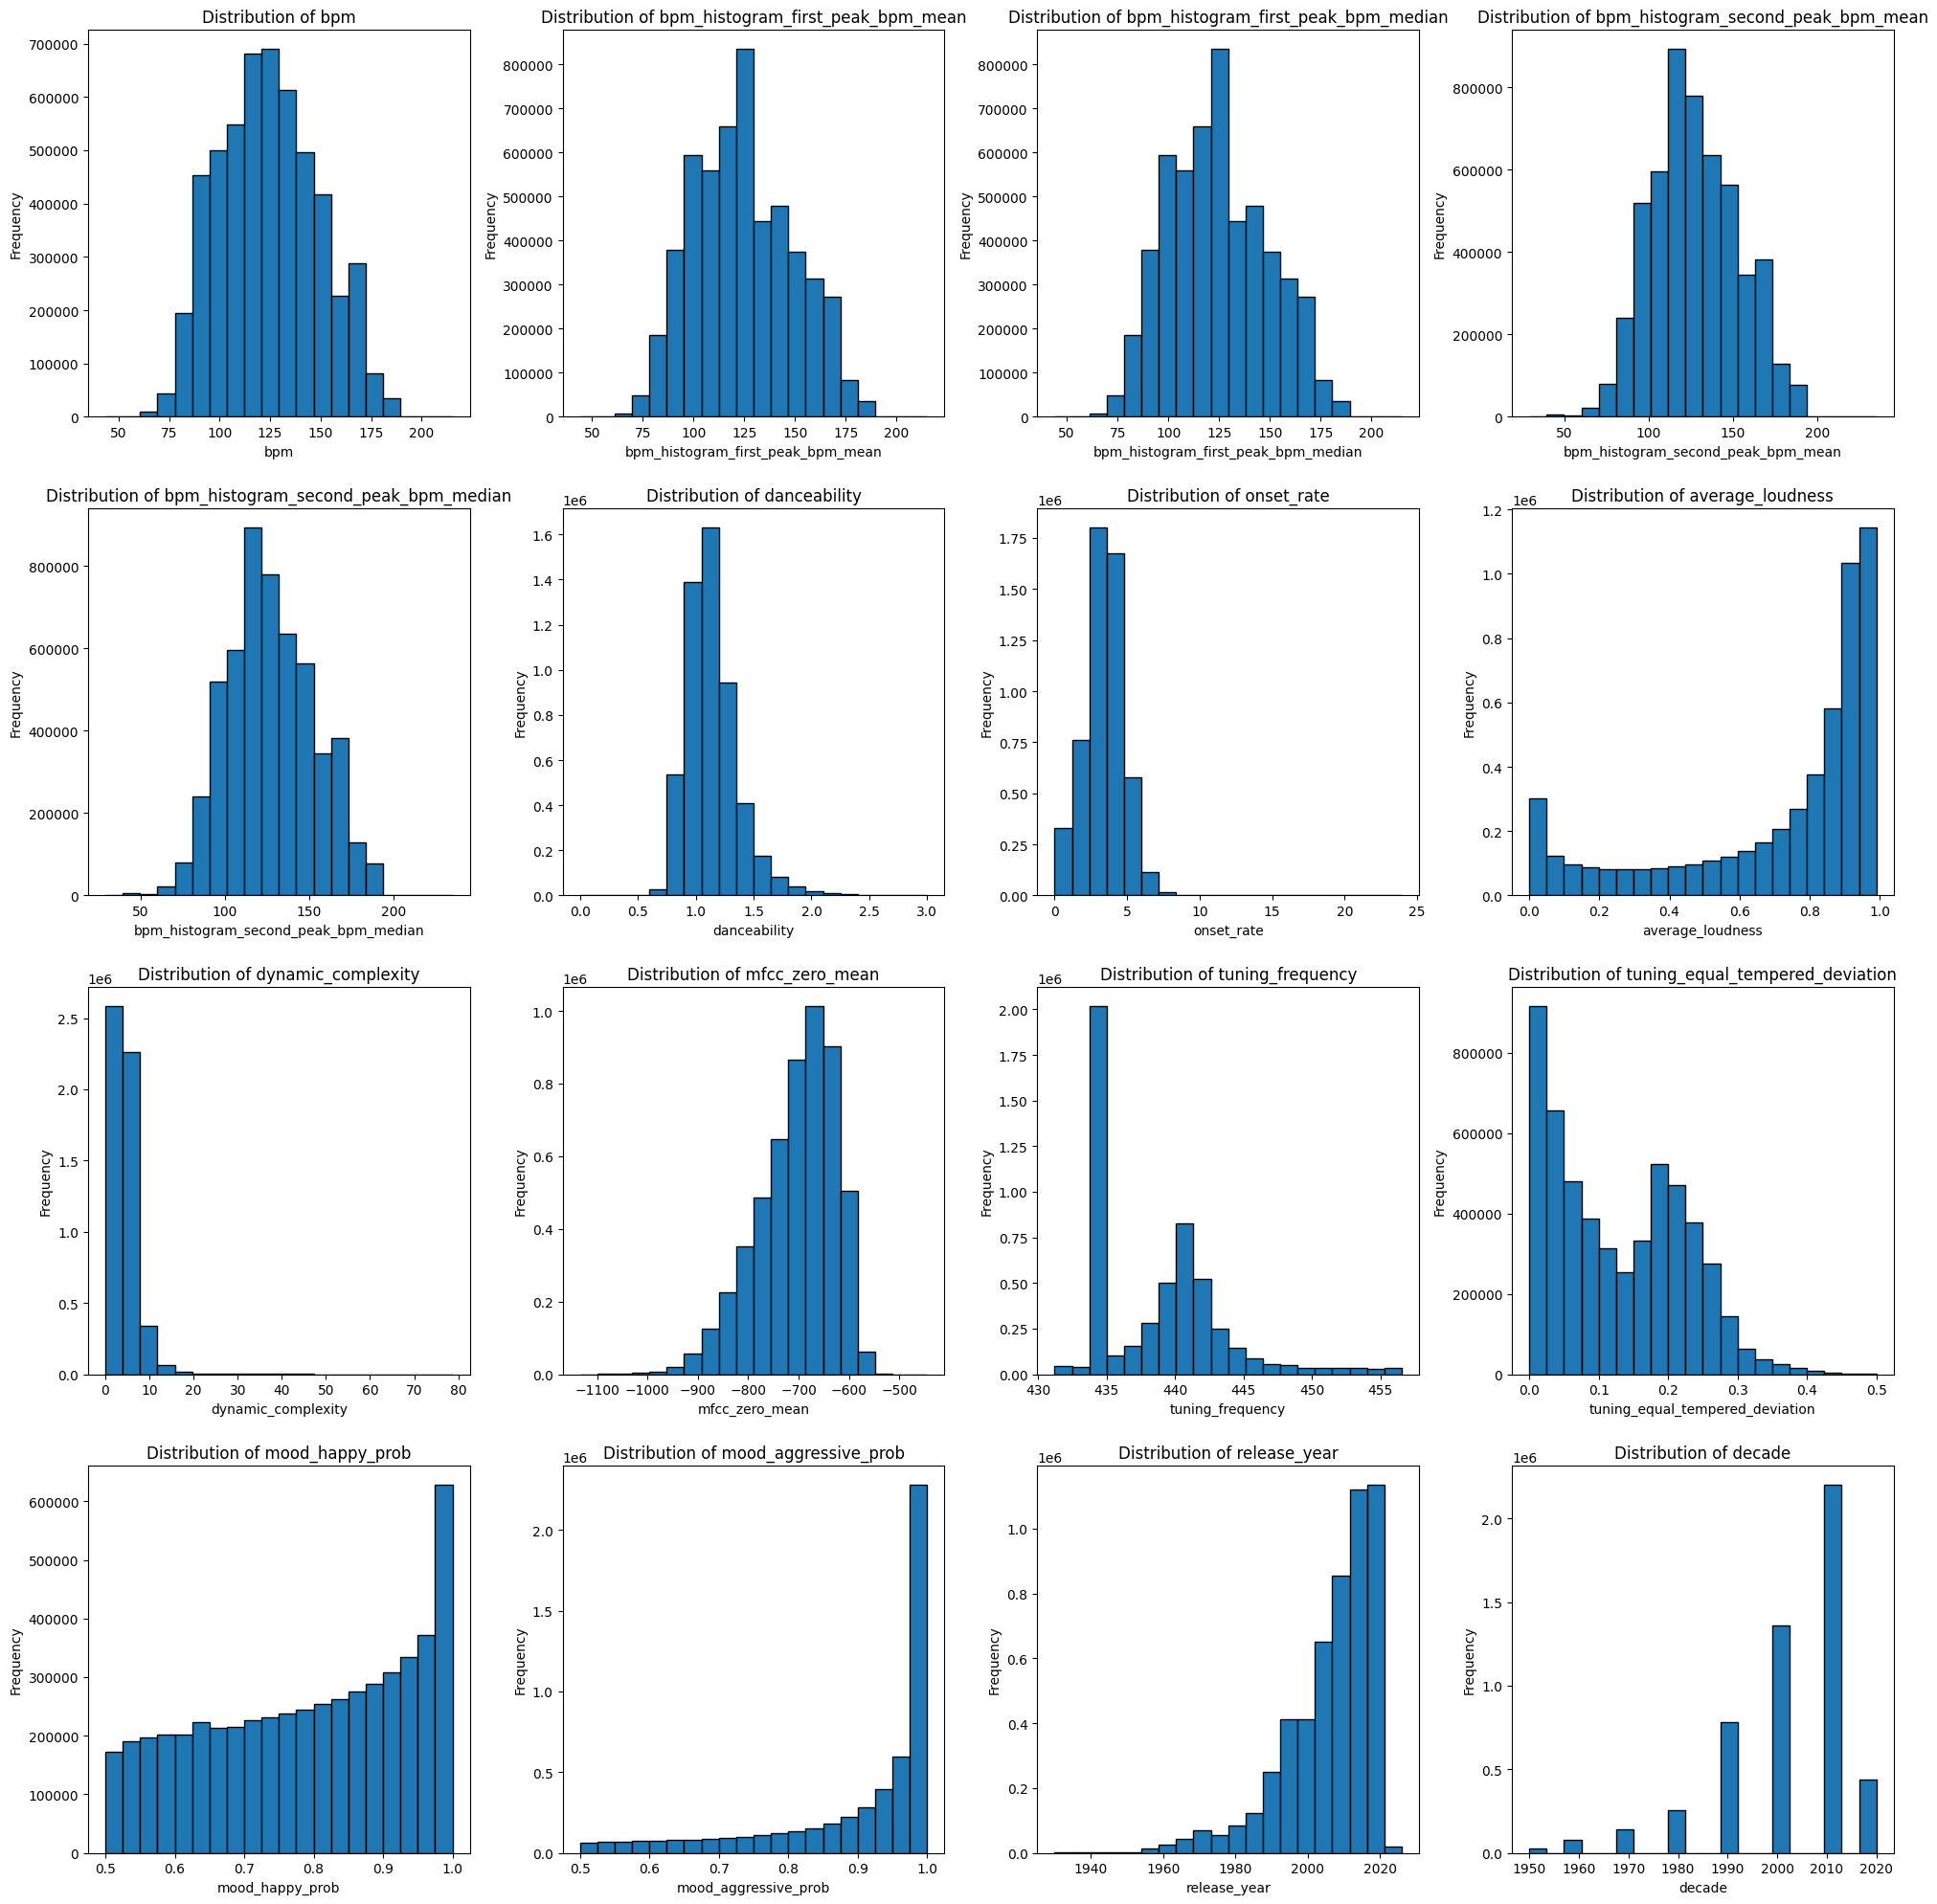

In [31]:
num_cols = len(numeric_cols)
n_cols = 4
n_rows = 4

fig, axes = plt.subplots(nrows=n_rows, ncols = n_cols, figsize=( 20,20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins = 20, edgecolor = 'black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


In [32]:
df.info()

<class 'pandas.DataFrame'>
Index: 5279256 entries, 0 to 5598785
Data columns (total 30 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_key                               str    
 14  key_scale                             str    
 15  mood_happy_prob                

In [33]:
df['key_key'].value_counts()

key_key
A     685221
F     637988
C     616094
D     608907
A#    600175
G     476288
E     422435
D#    273998
C#    272973
G#    248600
B     223166
F#    213411
Name: count, dtype: int64

Decide to one hot encode keys

In [34]:
df = pd.get_dummies(df, columns = ['key_key'], dtype = int)

Set the binary variables to 0 and 1

In [35]:
df['key_scale'].value_counts()

key_scale
major    2967551
minor    2311705
Name: count, dtype: int64

In [36]:
df['key_scale'] = df['key_scale'].map({'major' : 1, 'minor' : 0})

In [37]:
df['mood_happy'].value_counts()

mood_happy
not_happy    3833581
happy        1445675
Name: count, dtype: int64

In [38]:
df['mood_happy'] = df['mood_happy'].map({'happy' : 1, 'not_happy' : 0})

In [39]:
df['mood_sad'].value_counts()

mood_sad
not_sad    3482046
sad        1797210
Name: count, dtype: int64

In [40]:
df['mood_sad'] = df['mood_sad'].map({'sad' : 1, 'not_sad' : 0})

In [41]:
df['mood_relaxed'].value_counts()

mood_relaxed
relaxed        3602566
not_relaxed    1676690
Name: count, dtype: int64

In [42]:
df['mood_relaxed'] = df['mood_relaxed'].map({'relaxed' : 1, 'not_relaxed' : 0})

In [43]:
df['mood_aggressive'].value_counts()

mood_aggressive
not_aggressive    4115395
aggressive        1163861
Name: count, dtype: int64

In [44]:
df['mood_aggressive'] = df['mood_aggressive'].map({'aggressive' : 1, 'not_aggressive' : 0})

In [45]:
df['mood_acoustic'].value_counts()

mood_acoustic
not_acoustic    3329947
acoustic        1949309
Name: count, dtype: int64

In [46]:
df['mood_acoustic'] = df['mood_acoustic'].map({'acoustic' : 1, 'not_acoustic' : 0})

In [47]:
df['mood_electronic'].value_counts()

mood_electronic
electronic        2909552
not_electronic    2369704
Name: count, dtype: int64

In [48]:
df['mood_electronic'] = df['mood_electronic'].map({'electronic' : 1, 'not_electronic' : 0})

In [49]:
df['mood_party'].value_counts()

mood_party
not_party    3509552
party        1769704
Name: count, dtype: int64

In [50]:
df['mood_party'] = df['mood_party'].map({'party' : 1, 'not_party' : 0})

In [51]:
df['voice_gender'].value_counts()

voice_gender
female    3113062
male      2166194
Name: count, dtype: int64

In [52]:
df['voice_gender'] = df['voice_gender'].map({'female' : 1, 'male' : 0})

In [53]:
df['timbre'].value_counts()

timbre
dark      2829672
bright    2449584
Name: count, dtype: int64

In [54]:
df['timbre'] = df['timbre'].map({'bright' : 1, 'dark' : 0})

In [55]:
df['tonal_atonal'].value_counts()

tonal_atonal
atonal    2973760
tonal     2305496
Name: count, dtype: int64

In [56]:
df['tonal_atonal'].isna().sum()

np.int64(0)

In [57]:
df['tonal_atonal'] = df['tonal_atonal'].map({'tonal' : 1, 'atonal' : 0})

In [58]:
df['voice_instrumental'].value_counts()

voice_instrumental
instrumental    2663614
voice           2615642
Name: count, dtype: int64

In [59]:
df['voice_instrumental'] = df['voice_instrumental'].map({'voice' : 1, 'instrumental' : 0})

In [60]:
df.info()

<class 'pandas.DataFrame'>
Index: 5279256 entries, 0 to 5598785
Data columns (total 41 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_scale                             int64  
 14  mood_happy_prob                       float64
 15  mood_aggressive_prob           

In [61]:
df.isna().sum()

mbid                                    0
bpm                                     0
bpm_histogram_first_peak_bpm_mean       0
bpm_histogram_first_peak_bpm_median     0
bpm_histogram_second_peak_bpm_mean      0
bpm_histogram_second_peak_bpm_median    0
danceability                            0
onset_rate                              0
average_loudness                        0
dynamic_complexity                      0
mfcc_zero_mean                          0
tuning_frequency                        0
tuning_equal_tempered_deviation         0
key_scale                               0
mood_happy_prob                         0
mood_aggressive_prob                    0
mood_happy                              0
mood_sad                                0
mood_relaxed                            0
mood_aggressive                         0
mood_acoustic                           0
mood_electronic                         0
mood_party                              0
voice_gender                      

Don't need mbid

In [62]:
df.drop(columns = ['mbid'], inplace = True)

Save as csv

In [63]:
df.to_csv('data/decades_cleaned.csv', index = False)